Inisialisasi dan Konfigurasi Direktori

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [1]:
# === Konfigurasi Jalur Data ===
train_dir = r"D:\TUGAS AKHIR\CNN\dataset\Train"
val_dir = r"D:\TUGAS AKHIR\CNN\dataset\Val"
test_dir = r"D:\TUGAS AKHIR\CNN\dataset\Test"

Pre-processing dan Augmentasi Data

In [3]:
# 1. Definisi Ukuran Target (Resizing)
img_size = (224, 224) 

# 2. Definisi Transformasi (Rescaling & Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,                # Normalisasi piksel (0-1)
    brightness_range=[0.8, 1.2],   # Augmentasi cahaya
    zoom_range=0.15,               # Augmentasi perbesaran
    shear_range=0.1,               # Augmentasi sudut
    horizontal_flip=True           # Augmentasi posisi
)

# Pre-processing untuk data validasi dan testing (hanya rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

Data Loaders

In [4]:
# Penggunaan batch_size di sini merujuk pada variabel yang akan didefinisikan di sel berikutnya
# Namun untuk alur program, kita bisa langsung set angka atau definisikan batch_size sementara
temp_batch = 16

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=temp_batch,
    class_mode='binary', shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=temp_batch,
    class_mode='binary', shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=1, # batch 1 untuk evaluasi per gambar
    class_mode='binary', shuffle=False
)

Found 6720 images belonging to 2 classes.
Found 480 images belonging to 2 classes.
Found 240 images belonging to 2 classes.


Konfigurasi Pelatihan / Hyperparameters

In [5]:
# === Hyperparameters Pelatihan ===
batch_size = 16
epochs = 30
learning_rate = 0.0008
momentum = 0.95

# === Callbacks Optimasi ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

Arsitektur Model AI dan Fine-Tuning

In [6]:
# 1. Base Model (Transfer Learning)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Strategi Fine-Tuning: Membuka 15 layer terakhir
base_model.trainable = True
for layer in base_model.layers[:-15]:
    layer.trainable = False

# 3. Custom Head Model (Top Layers)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(0.5)(x)
x = BatchNormalization()(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,304,257 (8.79 MB)

 Trainable params: 1,083,649 (4.13 MB)

 Non-trainable params: 1,220,608 (4.66 MB)

Compile dan Proses Pelatihan

In [7]:
# Compile menggunakan SGD sesuai judul file Anda
optimizer = SGD(learning_rate=learning_rate, momentum=momentum, nesterov=True)
model.compile(optimizer=optimizer, loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1), metrics=['accuracy'])

# Eksekusi Training
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

D:\TUGAS AKHIR\CNN\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 346s 783ms/step - accuracy: 0.8196 - loss: 0.5370 - val_accuracy: 0.5000 - val_loss: 4.0853 - learning_rate: 8.0000e-04
Epoch 2/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 309s 735ms/step - accuracy: 0.8818 - loss: 0.4536 - val_accuracy: 0.5104 - val_loss: 1.6080 - learning_rate: 8.0000e-04
Epoch 3/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 280s 667ms/step - accuracy: 0.9051 - loss: 0.4222 - val_accuracy: 0.5771 - val_loss: 1.0433 - learning_rate: 8.0000e-04
Epoch 4/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 259s 617ms/step - accuracy: 0.9073 - loss: 0.4132 - val_accuracy: 0.7208 - val_loss: 0.8009 - learning_rate: 8.0000e-04
Epoch 5/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 261s 620ms/step - accuracy: 0.9220 - loss: 0.4016 - val_accuracy: 0.6833 - val_loss: 0.8116 - learning_rate: 8.0000e-04
Epoch 6/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 259s 616ms/step - accuracy: 0.9140 - loss: 0.4042 - val_accuracy: 0.8667 - val_loss: 0.4655 - learning_rate: 8.0000e-04
Epoch 7/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 

Evaluasi dan Analisis Hasil

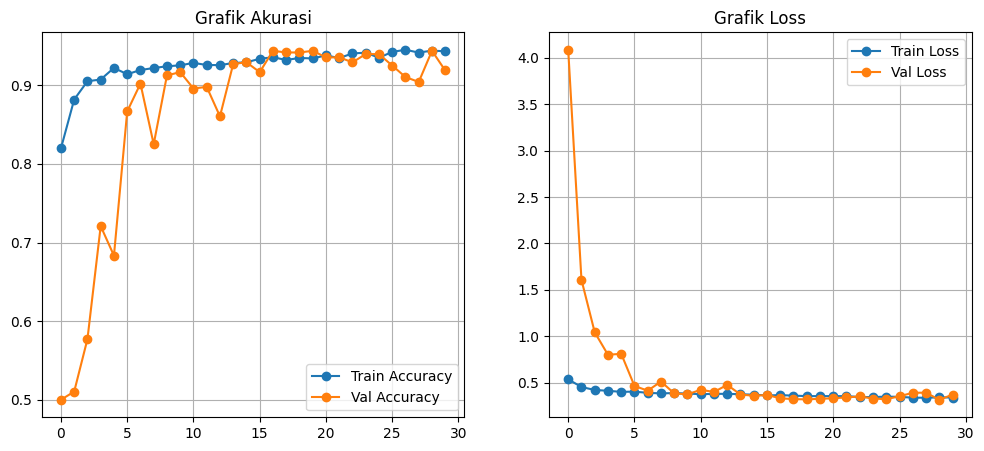

240/240 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step

=== Classification Report ===
                precision    recall  f1-score   support

      Berkabut       0.92      1.00      0.96       120
Tidak Berkabut       1.00      0.91      0.95       120

      accuracy                           0.95       240
     macro avg       0.96      0.95      0.95       240
  weighted avg       0.96      0.95      0.95       240



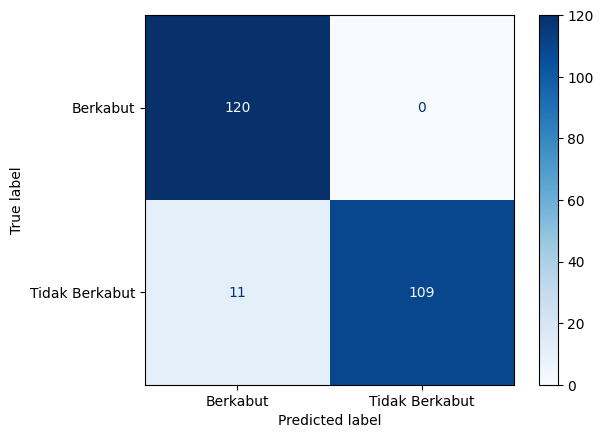


Rata-rata keyakinan prediksi 'Berkabut' (<0.5): 0.071
Rata-rata keyakinan prediksi 'Tidak Berkabut' (>0.5): 0.852


In [8]:
# 1. Grafik Akurasi dan Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Grafik Akurasi')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Grafik Loss')
plt.legend(); plt.grid(True)
plt.show()

# 2. Confusion Matrix & Classification Report
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=['Berkabut', 'Tidak Berkabut']))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Berkabut', 'Tidak Berkabut'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Hitung probabilitas rata-rata untuk insight keyakinan model
avg_conf_foggy = np.mean(y_pred_prob[y_true == 0]) if np.any(y_true == 0) else None
avg_conf_clear = np.mean(y_pred_prob[y_true == 1]) if np.any(y_true == 1) else None

print(f"\nRata-rata keyakinan prediksi 'Berkabut' (<0.5): {avg_conf_foggy:.3f}")
print(f"Rata-rata keyakinan prediksi 'Tidak Berkabut' (>0.5): {avg_conf_clear:.3f}")

In [9]:
# === Evaluasi Test ===
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\n✅ Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9542 - loss: 0.3083

✅ Test Accuracy: 0.9542 | Test Loss: 0.3083


TESTING

In [10]:
img_path = r'D:\TUGAS AKHIR\CNN\dataset\Test\Berkabut\20250508164442.jpg'
img_size = (224, 224)

img = tf.keras.utils.load_img(img_path, target_size=img_size)
img_array = tf.keras.utils.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)
label = 'Tidak Berkabut' if pred > 0.5 else 'Berkabut'
print(f"Gambar: {img_path} | Prediksi: {label} | Probabilitas: {pred[0][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Gambar: D:\TUGAS AKHIR\CNN\dataset\Test\Berkabut\20250508164442.jpg | Prediksi: Berkabut | Probabilitas: 0.0522


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
Gambar: D:\TUGAS AKHIR\CNN\dataset\Test\Berkabut\20250508164442.jpg
Prediksi: Berkabut
Probabilitas mentah: 0.0522
Keyakinan: 94.78%


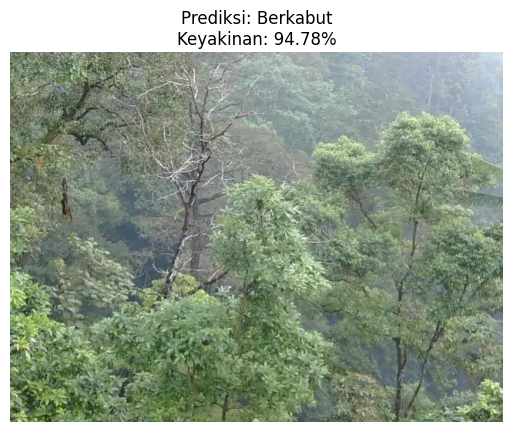

In [11]:
# Path ke gambar uji
img_path = r'D:\TUGAS AKHIR\CNN\dataset\Test\Berkabut\20250508164442.jpg'
img_size = (224, 224)

# Load dan preprocess gambar
img = tf.keras.utils.load_img(img_path, target_size=img_size)
img_array = tf.keras.utils.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediksi
pred = model.predict(img_array)
pred_value = pred[0][0]

if pred_value > 0.5:
    label = 'Tidak Berkabut'
    confidence = pred_value * 100
else:
    label = 'Berkabut'
    confidence = (1 - pred_value) * 100

# Cetak hasil
print(f"Gambar: {img_path}")
print(f"Prediksi: {label}")
print(f"Probabilitas mentah: {pred_value:.4f}")
print(f"Keyakinan: {confidence:.2f}%")

# Tampilkan gambar
plt.imshow(tf.keras.utils.load_img(img_path))
plt.axis('off')
plt.title(f"Prediksi: {label}\nKeyakinan: {confidence:.2f}%")
plt.show()